In [14]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "cleaned_output/Fitbit_lo_cleaned"


In [15]:
sleep_df   = pd.read_excel(f"{BASE_DIR}/Fitbit_lo_sleep_score_cleaned.xlsx")
stress_df  = pd.read_excel(f"{BASE_DIR}/Fitbit_lo_stress_score_cleaned.xlsx")
activity_df = pd.read_excel(f"{BASE_DIR}/Fitbit_lo_active_zone_minutes_(azm)_cleaned.xlsx")


In [16]:
sleep_df.columns, stress_df.columns, activity_df.columns

(Index(['sleep_log_entry_id', 'timestamp', 'overall_score', 'composition_score',
        'revitalization_score', 'duration_score', 'deep_sleep_in_minutes',
        'resting_heart_rate', 'restlessness', 'source_file'],
       dtype='object'),
 Index(['date', 'updated_at', 'stress_score', 'sleep_points',
        'max_sleep_points', 'responsiveness_points',
        'max_responsiveness_points', 'exertion_points', 'max_exertion_points',
        'status', 'calculation_failed', 'source_file'],
       dtype='object'),
 Index(['date_time', 'heart_zone_id', 'total_minutes', 'source_file'], dtype='object'))

In [17]:
sleep_df["date"] = pd.to_datetime(
    sleep_df["timestamp"], errors="coerce"
).dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

sleep_daily.head()


,date,sleep_score
0,2025-07-06,76.0
1,2025-07-07,76.0
2,2025-07-08,86.0
3,2025-07-09,75.0
4,2025-07-10,78.0


In [18]:
stress_df["date"] = pd.to_datetime(
    stress_df["date"], errors="coerce"
).dt.date

stress_daily = stress_df[["date", "stress_score"]]

stress_daily.head()


,date,stress_score
0,2025-07-06,68
1,2025-07-07,77
2,2025-07-08,81
3,2025-07-09,79
4,2025-07-10,83


In [19]:
activity_df["date"] = pd.to_datetime(
    activity_df["date_time"], errors="coerce"
).dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)

activity_daily.head()


,date,active_minutes
0,2025-07-05,24
1,2025-07-06,43
2,2025-07-07,5
3,2025-07-08,112
4,2025-07-09,78


In [20]:
daily_lo = sleep_daily.merge(stress_daily, on="date", how="left")
daily_lo = daily_lo.merge(activity_daily, on="date", how="left")

daily_lo


,date,sleep_score,stress_score,active_minutes
0,2025-07-06,76.0,68.0,43.0
1,2025-07-07,76.0,77.0,5.0
2,2025-07-08,86.0,81.0,112.0
3,2025-07-09,75.0,79.0,78.0
4,2025-07-10,78.0,83.0,1.0
5,2025-07-14,77.0,79.0,34.0
6,2025-07-15,81.0,86.0,25.0
7,2025-07-16,80.0,84.0,56.0
8,2025-07-17,65.0,NaN,11.0
9,2025-07-18,81.0,NaN,5.0


In [21]:
daily_lo.info()
daily_lo.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            19 non-null     object 
 1   sleep_score     19 non-null     float64
 2   stress_score    14 non-null     float64
 3   active_minutes  17 non-null     float64
dtypes: float64(3), object(1)
memory usage: 740.0+ bytes


,sleep_score,stress_score,active_minutes
count,19.000000,14.000000,17.000000
mean,76.842105,72.500000,23.823529
std,5.377558,21.410817,31.737666
min,64.000000,0.000000,1.000000
25%,75.500000,75.000000,4.000000
50%,77.000000,78.000000,7.000000
75%,80.000000,80.750000,34.000000
max,86.000000,86.000000,112.000000


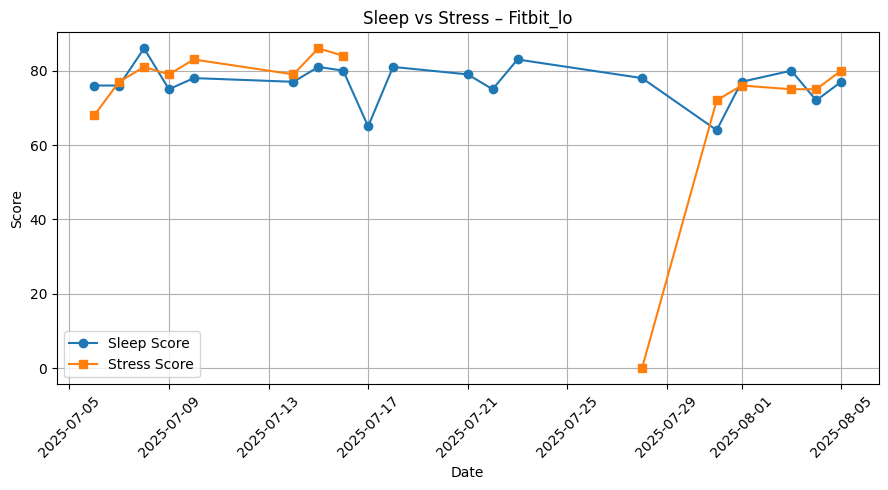

In [22]:
plt.figure(figsize=(9,5))
plt.plot(daily_lo["date"], daily_lo["sleep_score"], marker="o", label="Sleep Score")
plt.plot(daily_lo["date"], daily_lo["stress_score"], marker="s", label="Stress Score")

plt.title("Sleep vs Stress – Fitbit_lo")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

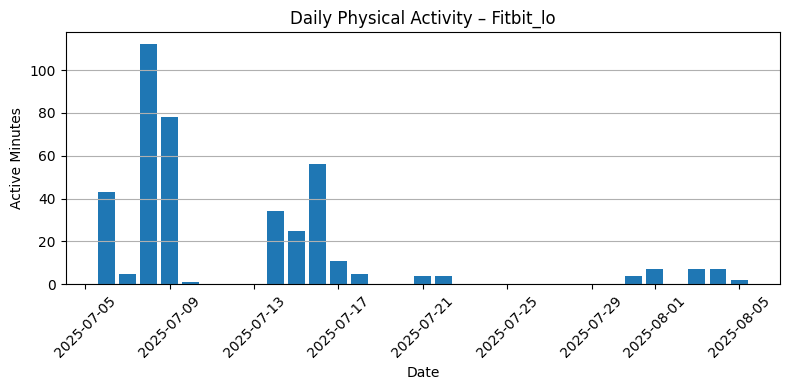

In [23]:
plt.figure(figsize=(8,4))
plt.bar(daily_lo["date"], daily_lo["active_minutes"])
plt.title("Daily Physical Activity – Fitbit_lo")
plt.xlabel("Date")
plt.ylabel("Active Minutes")
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
daily_lo[["sleep_score", "stress_score", "active_minutes"]].corr()

,sleep_score,stress_score,active_minutes
sleep_score,1.000000,0.066579,0.408242
stress_score,0.066579,1.000000,0.216110
active_minutes,0.408242,0.216110,1.000000


Behavioural & Physiological Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
BASE_DIR = "cleaned_output/Fitbit_lo_cleaned"


In [5]:
import pandas as pd

sleep_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_lo_sleep_score_cleaned.xlsx"
)

sleep_df["date"] = pd.to_datetime(
    sleep_df["timestamp"], errors="coerce"
).dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

sleep_daily.head()


,date,sleep_score
0,2025-07-06,76.0
1,2025-07-07,76.0
2,2025-07-08,86.0
3,2025-07-09,75.0
4,2025-07-10,78.0


In [6]:
sleep_df.columns


Index(['sleep_log_entry_id', 'timestamp', 'overall_score', 'composition_score',
       'revitalization_score', 'duration_score', 'deep_sleep_in_minutes',
       'resting_heart_rate', 'restlessness', 'source_file', 'date'],
      dtype='object')

In [7]:
stress_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_lo_stress_score_cleaned.xlsx"
)

stress_df["date"] = pd.to_datetime(
    stress_df["date"], errors="coerce"
).dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)


In [8]:
activity_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_lo_active_zone_minutes_(azm)_cleaned.xlsx"
)

activity_df["date"] = pd.to_datetime(
    activity_df["date_time"], errors="coerce"
).dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)


In [9]:
hrv_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_lo_heart_rate_variability_cleaned.xlsx"
)

hrv_df["date"] = pd.to_datetime(
    hrv_df["timestamp"], errors="coerce"
).dt.date

hrv_daily = (
    hrv_df
    .groupby("date")["rmssd"]
    .mean()
    .reset_index(name="hrv_rmssd")
)


In [10]:
temp_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_lo_temperature_cleaned.xlsx"
)

temp_df["date"] = pd.to_datetime(
    temp_df["sleep_start"], errors="coerce"
).dt.date

temp_daily = (
    temp_df
    .groupby("date")["temperature"]
    .mean()
    .reset_index(name="nightly_temp")
)


In [11]:
import os
os.listdir(BASE_DIR)


['Fitbit_lo_active_zone_minutes_(azm)_cleaned.xlsx',
 'Fitbit_lo_activity_goals_cleaned.xlsx',
 'Fitbit_lo_biometrics_cleaned.xlsx',
 'Fitbit_lo_heart_rate_variability_cleaned.xlsx',
 'Fitbit_lo_oxygen_saturation_(spo2)_cleaned.xlsx',
 'Fitbit_lo_physical_activity_googledata_cleaned.xlsx',
 'Fitbit_lo_sleep_score_cleaned.xlsx',
 'Fitbit_lo_stress_score_cleaned.xlsx',
 'Fitbit_lo_temperature_cleaned.xlsx']

In [12]:
# Start from sleep as the base
daily_lo = sleep_daily.copy()

# Merge stress
daily_lo = daily_lo.merge(
    stress_daily,
    on="date",
    how="left"
)

# Merge activity
daily_lo = daily_lo.merge(
    activity_daily,
    on="date",
    how="left"
)

# Merge HRV
daily_lo = daily_lo.merge(
    hrv_daily,
    on="date",
    how="left"
)

# Merge temperature
daily_lo = daily_lo.merge(
    temp_daily,
    on="date",
    how="left"
)

daily_lo


,date,sleep_score,stress_score,active_minutes,hrv_rmssd,nightly_temp
0,2025-07-06,76.0,68.0,43.0,39.754728,NaN
1,2025-07-07,76.0,77.0,5.0,40.060349,NaN
2,2025-07-08,86.0,81.0,112.0,81.379816,0.0
3,2025-07-09,75.0,79.0,78.0,33.731171,0.0
4,2025-07-10,78.0,83.0,1.0,39.579663,NaN
5,2025-07-14,77.0,79.0,34.0,35.638813,NaN
6,2025-07-15,81.0,86.0,25.0,39.789782,0.0
7,2025-07-16,80.0,84.0,56.0,38.314239,0.0
8,2025-07-17,65.0,NaN,11.0,28.153865,NaN
9,2025-07-18,81.0,NaN,5.0,32.806764,NaN


In [13]:
daily_lo.info()
daily_lo.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            19 non-null     object 
 1   sleep_score     19 non-null     float64
 2   stress_score    14 non-null     float64
 3   active_minutes  17 non-null     float64
 4   hrv_rmssd       19 non-null     float64
 5   nightly_temp    7 non-null      float64
dtypes: float64(5), object(1)
memory usage: 1.0+ KB


,sleep_score,stress_score,active_minutes,hrv_rmssd,nightly_temp
count,19.000000,14.000000,17.000000,19.000000,7.0
mean,76.842105,72.500000,23.823529,36.001649,0.0
std,5.377558,21.410817,31.737666,14.235319,0.0
min,64.000000,0.000000,1.000000,0.000000,0.0
25%,75.500000,75.000000,4.000000,32.110901,0.0
50%,77.000000,78.000000,7.000000,35.508024,0.0
75%,80.000000,80.750000,34.000000,39.667195,0.0
max,86.000000,86.000000,112.000000,81.379816,0.0


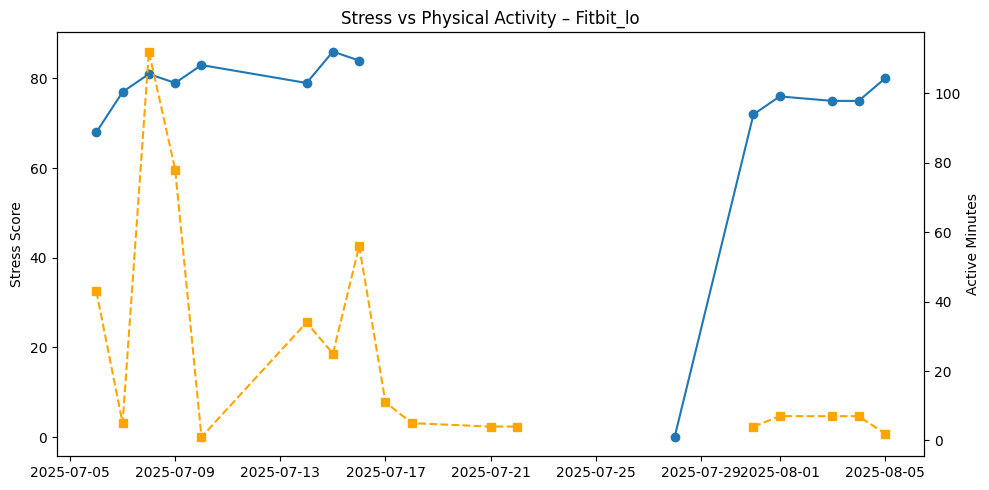

In [14]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    daily_lo["date"],
    daily_lo["stress_score"],
    marker="o",
    label="Stress Score"
)
ax1.set_ylabel("Stress Score")

ax2 = ax1.twinx()
ax2.plot(
    daily_lo["date"],
    daily_lo["active_minutes"],
    marker="s",
    linestyle="--",
    color="orange",
    label="Active Minutes"
)
ax2.set_ylabel("Active Minutes")

plt.title("Stress vs Physical Activity – Fitbit_lo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


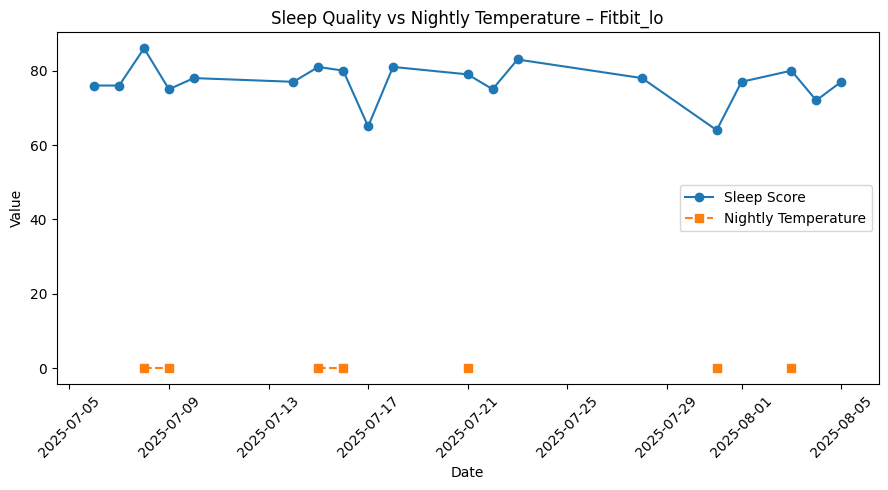

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    daily_lo["date"],
    daily_lo["sleep_score"],
    marker="o",
    label="Sleep Score"
)

plt.plot(
    daily_lo["date"],
    daily_lo["nightly_temp"],
    marker="s",
    linestyle="--",
    label="Nightly Temperature"
)

plt.title("Sleep Quality vs Nightly Temperature – Fitbit_lo")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


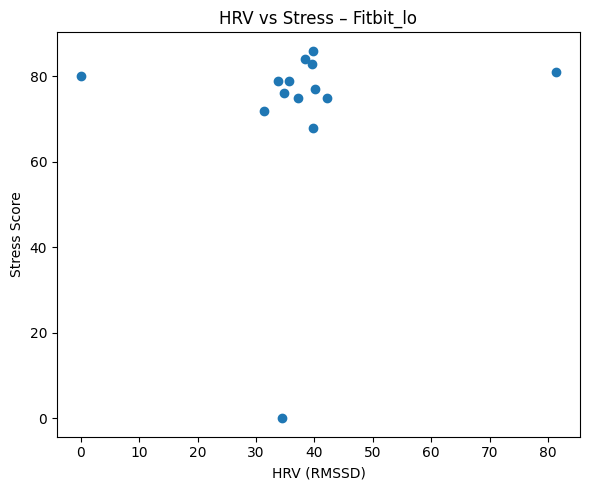

In [16]:
plt.figure(figsize=(6, 5))

plt.scatter(
    daily_lo["hrv_rmssd"],
    daily_lo["stress_score"]
)

plt.xlabel("HRV (RMSSD)")
plt.ylabel("Stress Score")
plt.title("HRV vs Stress – Fitbit_lo")
plt.tight_layout()
plt.show()


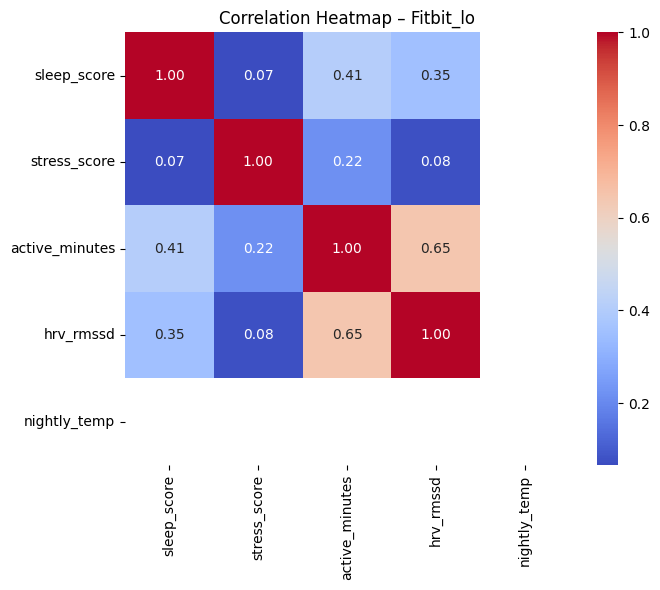

In [17]:
import seaborn as sns

numeric_lo = daily_lo.select_dtypes(include="number")

plt.figure(figsize=(7, 6))
sns.heatmap(
    numeric_lo.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap – Fitbit_lo")
plt.tight_layout()
plt.show()
